In [1]:
import sys
import xarray as xr
import numpy as np
from matplotlib import pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature
import geopandas as gpd
from shapely.geometry import mapping
from scipy.stats import spearmanr, pearsonr
import ts_onset_cess as ocd
import pandas as pd
import datetime

import warnings
warnings.filterwarnings('ignore')

In [2]:
fpl = []

#Know the year range being analysed (could scrape the date from the filename but this is easier)
#Loop through possible times and "try"
#Know that there are three files per month
for Y in range(2014,2025):
    for M in range(1,13):
        for D in [10,20,28,29,30,31]:
            try: 
                if Y < 2020:
                    fname = '/Volumes/ESA_F4R/clms/clms_fapar_300m_v1_10daily/fapar300/central_africa/c_gls_FAPAR300_'+str(Y)+str("{:02d}".format(M))+str(D)+'0000_GLOBE_PROBAV_V1.0.1_central_africa.nc' 
                    fp = xr.open_mfdataset(fname)['FAPAR']
                    #assign a datetime value to each xarray based on the date in the filename
                    fp = fp.assign_coords({"time":datetime.datetime(Y,M,D)})
                elif Y > 2020:
                    fname = '/Volumes/ESA_F4R/clms/clms_fapar_300m_v1_10daily/fapar300rt6/central_africa/c_gls_FAPAR300-RT6_'+str(Y)+str("{:02d}".format(M))+str(D)+'0000_GLOBE_OLCI_V1.1.2_central_africa.nc'
                    fp = xr.open_mfdataset(fname)['FAPAR']
                else:
                    if M < 9:
                        fname = '/Volumes/ESA_F4R/clms/clms_fapar_300m_v1_10daily/fapar300/central_africa/c_gls_FAPAR300_'+str(Y)+str("{:02d}".format(M))+str(D)+'0000_GLOBE_PROBAV_V1.0.1_central_africa.nc' 
                        fp = xr.open_mfdataset(fname)['FAPAR']
                        fp = fp.assign_coords({"time":datetime.datetime(Y,M,D)})
                    if M > 8:
                        fname = '/Volumes/ESA_F4R/clms/clms_fapar_300m_v1_10daily/fapar300rt6/central_africa/c_gls_FAPAR300-RT6_'+str(Y)+str("{:02d}".format(M))+str(D)+'0000_GLOBE_OLCI_V1.1.2_central_africa.nc'
                        fp = xr.open_mfdataset(fname)['FAPAR']
                fp = fp.sortby("lat", ascending=True)
                fp = fp.sel(lat=slice(-15,12),lon=slice(10,30))
                #print(fp)
                #print(fname)
                #append each xarray to a list
                fpl.append(fp)
            except:
                pass
#concatenate all xarrays in list to one single dataarray
fpt = xr.concat(fpl,dim='time')
print(fpt)


<xarray.DataArray 'FAPAR' (time: 1, lat: 9072, lon: 6720)> Size: 488MB
dask.array<getitem, shape=(1, 9072, 6720), dtype=float64, chunksize=(1, 3360, 3584), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) datetime64[ns] 8B 2024-11-30
  * lat      (lat) float64 73kB -15.0 -15.0 -14.99 -14.99 ... 11.99 11.99 12.0
  * lon      (lon) float64 54kB 10.0 10.0 10.01 10.01 ... 29.99 29.99 29.99 30.0
Attributes:
    standard_name:  fraction_of_surface_downwelling_photosynthetic_radiative_...
    long_name:      Fraction of Absorbed Photosynthetically Active Radiation ...
    grid_mapping:   crs
    units:          
    valid_range:    [  0 235]
<xarray.DataArray 'FAPAR' (lat: 9072, lon: 6720, time: 364)> Size: 178GB
dask.array<concatenate, shape=(9072, 6720, 364), dtype=float64, chunksize=(3360, 3584, 1), chunktype=numpy.ndarray>
Coordinates:
  * lat      (lat) float64 73kB -15.0 -15.0 -14.99 -14.99 ... 11.99 11.99 12.0
  * lon      (lon) float64 54kB 10.0 10.0 10.01 10.01 ... 29.99 29.

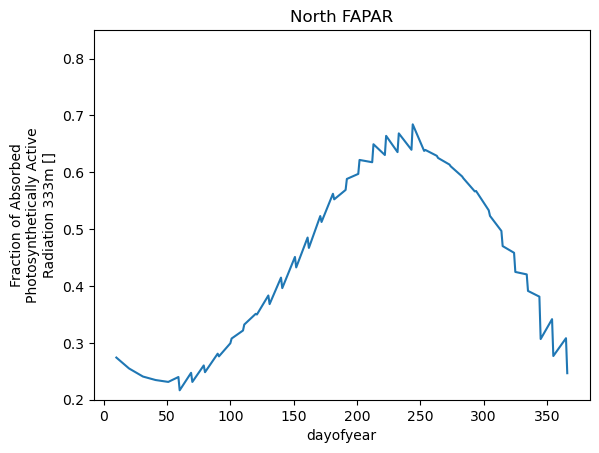

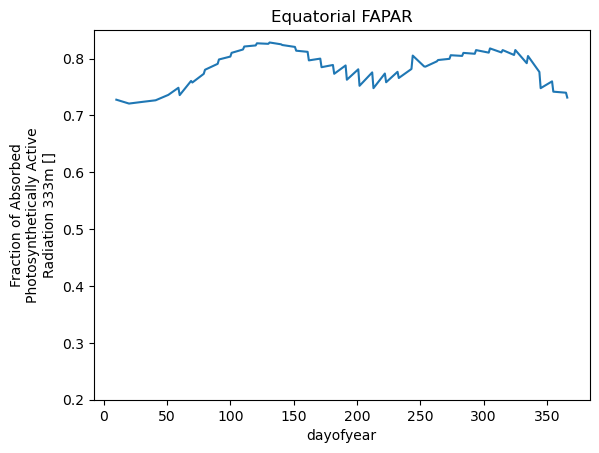

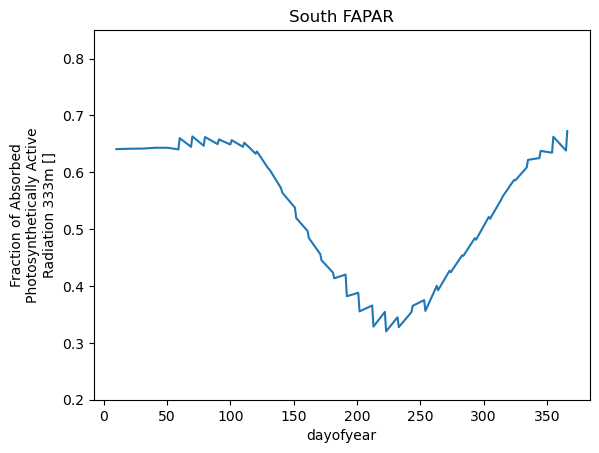

<Figure size 640x480 with 0 Axes>

In [4]:
#Plot climatology

fpN = fpt.sel(lat=slice(5,12))
fpN = fpN.mean(dim=('lat','lon'))
fpN = fpN.groupby('time.dayofyear').mean('time')
fpN.plot()
plt.title('North FAPAR')
plt.ylim(0.2,0.85)
plt.show()
plt.clf()

fpE = fpt.sel(lat=slice(-5,5))
fpE = fpE.mean(dim=('lat','lon'))
fpE = fpE.groupby('time.dayofyear').mean('time')
fpE.plot()
plt.title('Equatorial FAPAR')
plt.ylim(0.2,0.85)
plt.show()
plt.clf()

fpS = fpt.sel(lat=slice(-15,-5))
fpS = fpS.mean(dim=('lat','lon'))
fpS = fpS.groupby('time.dayofyear').mean('time')
fpS.plot()
plt.title('South FAPAR')
plt.ylim(0.2,0.85)
plt.show()
plt.clf()

In [ ]:
fpt.to_netcdf("/Volumes/ESA_F4R/clms/FAPAR_out/fapar_ca.nc",engine='h5netcdf')